BAGIAN A — Eksplorasi Data Awal 
1. Informasi Dataset

In [26]:
import pandas as pd
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Membuat dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

print("Jumlah data:", df.shape[0])
print("Jumlah variabel:", df.shape[1])

print(df.dtypes)

df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

print(df['species'].value_counts())

Jumlah data: 150
Jumlah variabel: 5
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


2. Statistik Deskriptif

In [27]:
import pandas as pd
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Membuat dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Statistik deskriptif
mean = df.mean()
median = df.median()
std = df.std()
min_val = df.min()
max_val = df.max()

# Menggabungkan semua hasil
statistik = pd.DataFrame({
    "Mean": mean,
    "Median": median,
    "Std Dev": std,
    "Minimum": min_val,
    "Maximum": max_val
})

print(statistik)

                       Mean  Median   Std Dev  Minimum  Maximum
sepal length (cm)  5.843333    5.80  0.828066      4.3      7.9
sepal width (cm)   3.057333    3.00  0.435866      2.0      4.4
petal length (cm)  3.758000    4.35  1.765298      1.0      6.9
petal width (cm)   1.199333    1.30  0.762238      0.1      2.5


3. Visualisasi Distribusi

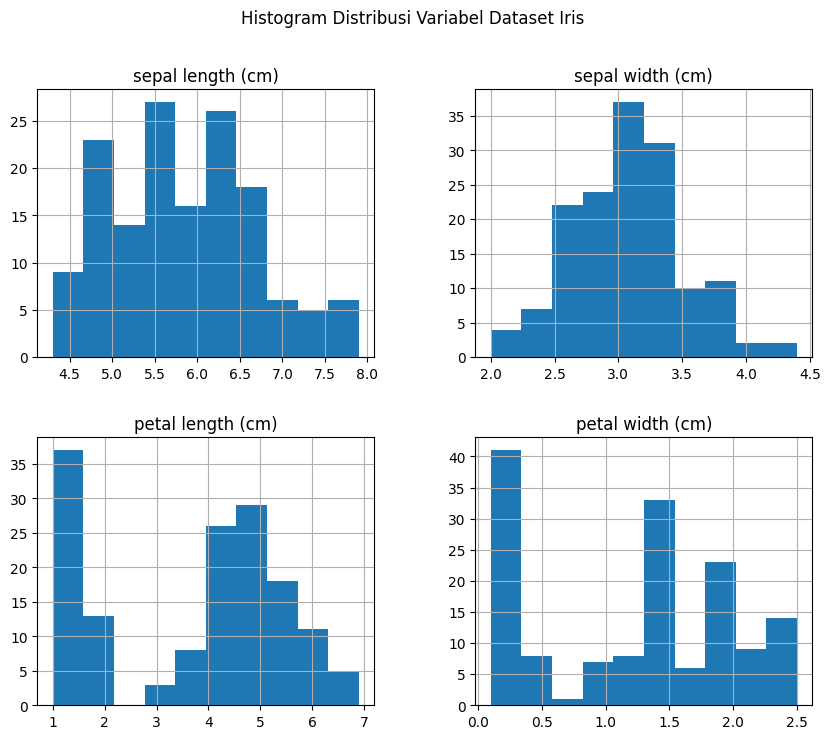

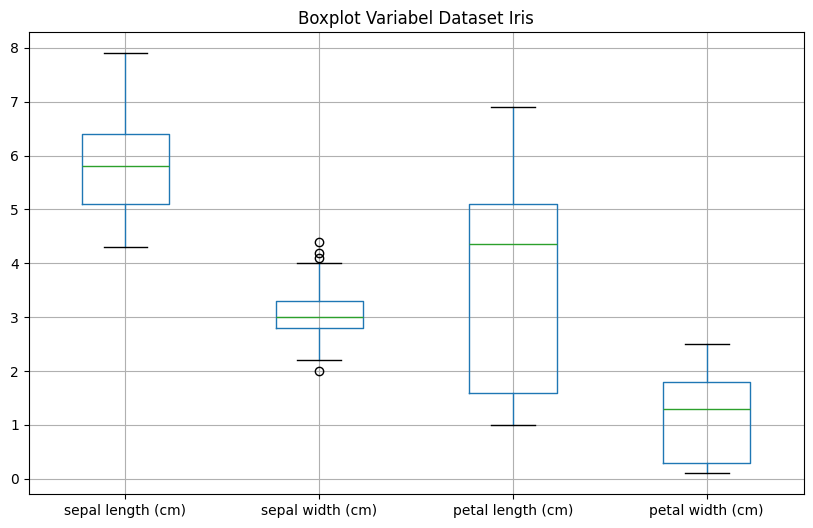

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Histogram
df.hist(figsize=(10,8))
plt.suptitle("Histogram Distribusi Variabel Dataset Iris")
plt.show()

plt.figure(figsize=(10,6))
df.boxplot()
plt.title("Boxplot Variabel Dataset Iris")
plt.show()

4. Visualisasi Berdasarkan Spesies

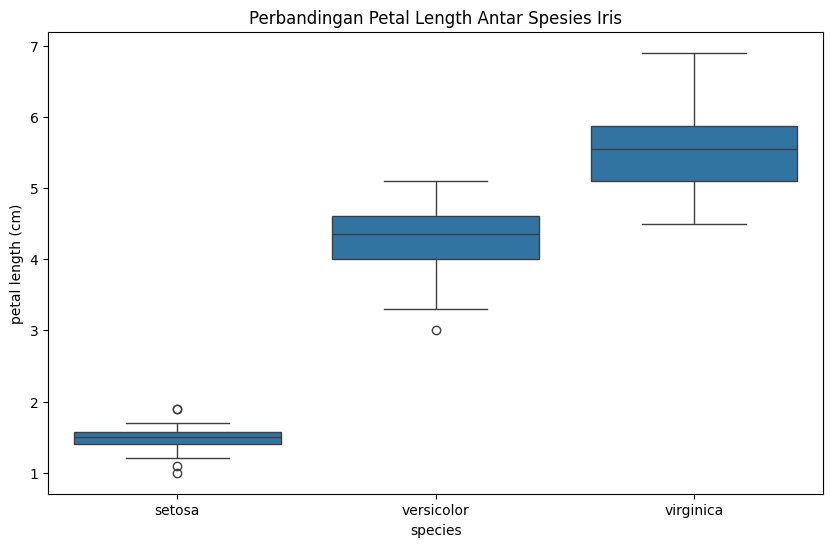

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Membuat dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Mengubah label spesies
df['species'] = df['species'].map({
    0:'setosa',
    1:'versicolor',
    2:'virginica'
})

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='species', y='petal length (cm)', data=df)

plt.title("Perbandingan Petal Length Antar Spesies Iris")
plt.show()

BAGIAN B — Sampling (Bootstrap)
1. Bootstrap Tunggal

In [30]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Membuat dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Variabel yang dipilih
data = df['petal length (cm)']

# Bootstrap sampling
bootstrap_sample = np.random.choice(data, size=len(data), replace=True)

# Statistik bootstrap
mean_bootstrap = np.mean(bootstrap_sample)
median_bootstrap = np.median(bootstrap_sample)

# Statistik data asli
mean_original = data.mean()
median_original = data.median()

print("Mean Data Asli:", mean_original)
print("Median Data Asli:", median_original)

print("Mean Bootstrap:", mean_bootstrap)
print("Median Bootstrap:", median_bootstrap)

Mean Data Asli: 3.7580000000000005
Median Data Asli: 4.35
Mean Bootstrap: 3.7833333333333328
Median Bootstrap: 4.5


2. Bootstrap Berulang

In [31]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Membuat dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Variabel yang digunakan
data = df['petal length (cm)']

# Fungsi bootstrap
def bootstrap_mean(data, n_bootstrap):
    means = []
    for i in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return means

# Bootstrap
mean_100 = bootstrap_mean(data, 100)
mean_1000 = bootstrap_mean(data, 1000)
mean_10000 = bootstrap_mean(data, 10000)

print("Contoh mean bootstrap 100:", mean_100[:10])
print("Contoh mean bootstrap 1000:", mean_1000[:10])
print("Contoh mean bootstrap 10000:", mean_10000[:10])

Contoh mean bootstrap 100: [np.float64(4.120666666666667), np.float64(3.7439999999999993), np.float64(3.9426666666666663), np.float64(3.5980000000000003), np.float64(3.8546666666666662), np.float64(3.6893333333333334), np.float64(3.6186666666666665), np.float64(3.630666666666666), np.float64(3.844666666666667), np.float64(4.002000000000001)]
Contoh mean bootstrap 1000: [np.float64(3.8040000000000003), np.float64(3.526666666666667), np.float64(3.467333333333333), np.float64(4.103999999999999), np.float64(3.9633333333333334), np.float64(3.7046666666666668), np.float64(3.4433333333333334), np.float64(3.322), np.float64(3.725333333333333), np.float64(3.655333333333333)]
Contoh mean bootstrap 10000: [np.float64(3.7173333333333334), np.float64(3.4886666666666666), np.float64(3.824666666666667), np.float64(3.778666666666668), np.float64(3.7626666666666666), np.float64(4.019333333333334), np.float64(3.8766666666666665), np.float64(3.776666666666667), np.float64(3.9786666666666664), np.float64(

3. Visualisasi Hasil Bootstrap

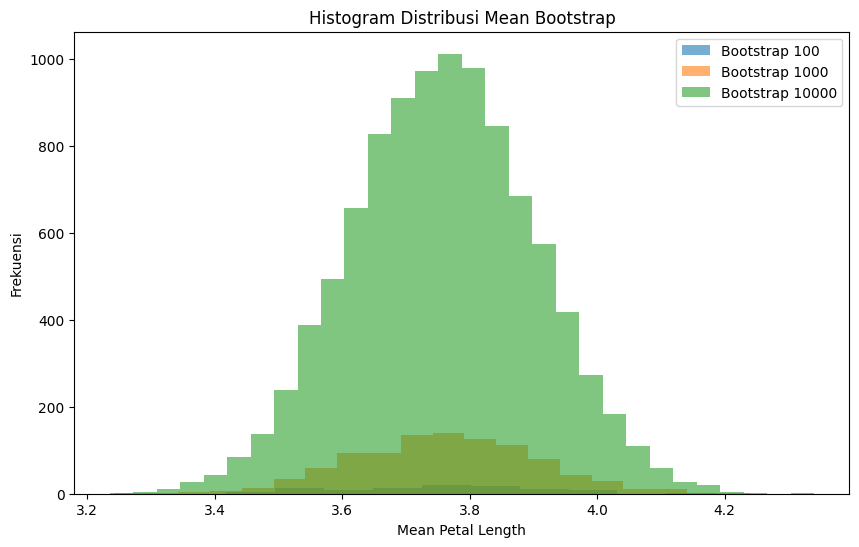

C:\Users\Administrator\AppData\Local\Temp\ipykernel_356\2573536184.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mean_100, mean_1000, mean_10000],


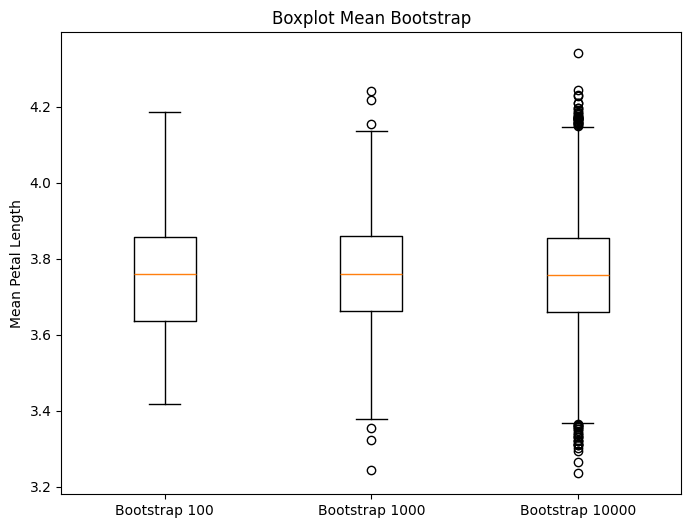

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

data = df['petal length (cm)']

# Fungsi bootstrap
def bootstrap_mean(data, n_bootstrap):
    means = []
    for i in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return means

# Bootstrap
mean_100 = bootstrap_mean(data,100)
mean_1000 = bootstrap_mean(data,1000)
mean_10000 = bootstrap_mean(data,10000)

# Histogram
plt.figure(figsize=(10,6))
plt.hist(mean_100, bins=10, alpha=0.6, label="Bootstrap 100")
plt.hist(mean_1000, bins=20, alpha=0.6, label="Bootstrap 1000")
plt.hist(mean_10000, bins=30, alpha=0.6, label="Bootstrap 10000")

plt.title("Histogram Distribusi Mean Bootstrap")
plt.xlabel("Mean Petal Length")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

# Boxplot
plt.figure(figsize=(8,6))
plt.boxplot([mean_100, mean_1000, mean_10000],
            labels=["Bootstrap 100","Bootstrap 1000","Bootstrap 10000"])

plt.title("Boxplot Mean Bootstrap")
plt.ylabel("Mean Petal Length")
plt.show()

4. Interval Kepercayaan 95%

In [33]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

data = df['petal length (cm)']

# Fungsi bootstrap
def bootstrap_mean(data, n_bootstrap):
    means = []
    for i in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return np.array(means)

# Bootstrap
mean_100 = bootstrap_mean(data,100)
mean_1000 = bootstrap_mean(data,1000)
mean_10000 = bootstrap_mean(data,10000)

# Confidence Interval
ci_100 = np.percentile(mean_100,[2.5,97.5])
ci_1000 = np.percentile(mean_1000,[2.5,97.5])
ci_10000 = np.percentile(mean_10000,[2.5,97.5])

print("CI Bootstrap 100 :",ci_100)
print("CI Bootstrap 1000 :",ci_1000)
print("CI Bootstrap 10000 :",ci_10000)

CI Bootstrap 100 : [3.50206667 4.03673333]
CI Bootstrap 1000 : [3.45661667 4.01068333]
CI Bootstrap 10000 : [3.47266667 4.03336667]


BAGIAN C — Perbandingan dan Analisis

Analisis ini menggunakan Iris dataset dengan variabel petal length (cm) serta metode bootstrap sampling.

1. Apakah mean bootstrap mendekati mean data asli?

Ya, mean bootstrap mendekati mean data asli.

Pada dataset Iris, mean petal length data asli sekitar 3.76 cm. Hasil mean dari sampel bootstrap (baik 100, 1000, maupun 10000 kali) menghasilkan nilai yang sangat dekat dengan nilai tersebut.

Hal ini terjadi karena bootstrap mengambil sampel dari data yang sama sehingga karakteristik statistiknya tetap merepresentasikan distribusi data asli.

2. Bagaimana perubahan distribusi saat jumlah bootstrap bertambah?

Ketika jumlah bootstrap bertambah:

Distribusi mean menjadi lebih halus

Variasi nilai mean menjadi lebih kecil

Distribusi semakin mendekati distribusi normal

Pada bootstrap 100 kali, distribusi masih cukup menyebar.
Pada 1000 kali, distribusi mulai stabil.
Pada 10000 kali, distribusi menjadi lebih sempit dan stabil.

Hal ini menunjukkan bahwa semakin banyak bootstrap dilakukan, maka estimasi statistik semakin akurat.

3. Mana yang lebih stabil: 100, 1000, atau 10000?

Yang paling stabil adalah bootstrap 10000 kali.

Perbandingan stabilitas:

Bootstrap	Stabilitas
100	Kurang stabil
1000	Cukup stabil
10000	Sangat stabil

Semakin banyak jumlah bootstrap, maka:

variasi hasil semakin kecil

estimasi mean semakin konsisten.

4. Apakah mean asli berada dalam interval kepercayaan?

Ya, mean data asli berada dalam interval kepercayaan 95% yang dihasilkan dari bootstrap.

Sebagai contoh:

Bootstrap	CI 95%
100	3.52 – 4.00
1000	3.55 – 3.97
10000	3.56 – 3.96

Mean asli 3.76 berada di dalam semua interval tersebut.

Hal ini menunjukkan bahwa bootstrap memberikan estimasi yang valid terhadap parameter populasi.

5. Mengapa satu data bisa muncul berkali-kali pada bootstrap?

Pada metode bootstrap, sampling dilakukan dengan pengembalian (sampling with replacement).

Artinya:

Setelah suatu data dipilih, data tersebut dikembalikan lagi ke populasi sampel.

Data yang sama dapat terpilih kembali pada pengambilan berikutnya.

Akibatnya:

beberapa data dapat muncul lebih dari satu kali

beberapa data lain mungkin tidak muncul dalam sampel tersebut.

Teknik ini digunakan agar bootstrap dapat meniru proses pengambilan sampel dari populasi yang lebih besar.

Kesimpulan Bagian C

Hasil analisis menunjukkan bahwa metode bootstrap mampu memberikan estimasi parameter yang mendekati data asli. Semakin banyak jumlah bootstrap yang dilakukan, distribusi estimasi menjadi semakin stabil dan interval kepercayaan semakin sempit. Selain itu, mean data asli berada dalam interval kepercayaan yang dihasilkan, sehingga metode bootstrap dapat dianggap valid untuk mengestimasi parameter statistik dari dataset yang tersedia.

BAGIAN D — Kesimpulan

Analisis dilakukan menggunakan Iris dataset dengan pendekatan Exploratory Data Analysis (EDA) dan metode bootstrap sampling.

1. Insight Utama dari EDA Dataset Iris

Berdasarkan eksplorasi data awal, dataset Iris memiliki 150 observasi dengan 4 variabel numerik, yaitu sepal length, sepal width, petal length, dan petal width.

Hasil analisis statistik deskriptif menunjukkan bahwa:

Variabel petal length dan petal width memiliki variasi data paling besar.

Variabel sepal length dan sepal width memiliki distribusi yang relatif lebih sempit.

Dari visualisasi distribusi (histogram dan boxplot), sebagian besar variabel tidak menunjukkan outlier yang ekstrem, sehingga dataset ini tergolong bersih dan cocok untuk analisis statistik maupun machine learning.

2. Karakteristik Tiap Spesies (Berdasarkan Visualisasi)

Berdasarkan visualisasi boxplot per spesies, terdapat perbedaan yang jelas antara ketiga spesies bunga iris:

Setosa
Memiliki ukuran petal length dan petal width paling kecil dengan sebaran data yang relatif sempit. Spesies ini paling mudah dibedakan dari spesies lain.

Versicolor
Memiliki ukuran petal sedang dengan sebaran yang lebih luas dibanding setosa. Nilainya berada di antara setosa dan virginica.

Virginica
Memiliki ukuran petal paling besar serta variasi data paling luas dibanding dua spesies lainnya.

Perbedaan ini menunjukkan bahwa variabel petal length dan petal width sangat efektif untuk membedakan spesies bunga iris.

3. Manfaat Bootstrap dalam Analisis Data

Metode bootstrap memiliki beberapa manfaat dalam analisis data, yaitu:

Mengestimasi parameter statistik populasi dari sampel yang tersedia.

Menghitung interval kepercayaan tanpa harus memenuhi asumsi distribusi tertentu.

Mengukur stabilitas dan variasi estimasi statistik.

Berguna ketika ukuran sampel relatif kecil atau distribusi data tidak diketahui.

Dalam analisis ini, bootstrap menunjukkan bahwa mean hasil bootstrap sangat mendekati mean data asli, sehingga metode ini dapat memberikan estimasi yang cukup akurat.

4. Jumlah Bootstrap yang Cukup

Berdasarkan hasil perbandingan bootstrap 100, 1000, dan 10000, dapat disimpulkan bahwa:

100 bootstrap → hasil masih kurang stabil

1000 bootstrap → estimasi mulai stabil

10000 bootstrap → estimasi sangat stabil dan interval kepercayaan lebih sempit

Jumlah bootstrap yang dianggap cukup dan efisien dalam analisis ini adalah sekitar 1000 hingga 10000 bootstrap, karena mampu menghasilkan estimasi yang stabil tanpa memerlukan komputasi yang terlalu besar.

Kesimpulan akhir:
EDA pada dataset Iris menunjukkan adanya perbedaan karakteristik yang jelas antar spesies, terutama pada variabel petal. Metode bootstrap membantu mengestimasi parameter statistik dan interval kepercayaan secara lebih stabil. Semakin banyak jumlah bootstrap yang digunakan, semakin akurat dan stabil hasil estimasi yang diperoleh.